<a href="https://colab.research.google.com/github/Saroj-lab/Assessment1/blob/main/Casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [104]:
import numpy as np
import pandas as pd

In [105]:
df_train = pd.read_csv('/content/Training_data.csv')
df_train.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [106]:
df_test = pd.read_csv('/content/Testing_data.csv')
df_test.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [107]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [108]:
df_train.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [109]:
df_train.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [110]:
df_train.duplicated().sum()

np.int64(0)

since there is no duplicate values, we can directly proceed to handling missing values. if the missing values are numbers, we replace it with median, if they are characters, we replace it with mode.

In [111]:
df_train['TotalCharges'] = pd.to_numeric(df_train['TotalCharges'], errors='coerce')

num_cols_median = [
   'MonthlyCharges','TotalCharges'

]
for col in num_cols_median:
    df_train[col] = df_train[col].fillna(df_train[col].median())

#df_train['gender','OnlineSecurity'] = df_train['gender','OnlineSecurity'].fillna(df_train['gender','OnlineSecurity'].mode()[0])
cat_cols = ['gender', 'OnlineSecurity']
for col in cat_cols:
    df_train[col] = df_train[col].fillna(df_train[col].mode()[0])

print("Remaining missing values:")
print(df_train.isnull().sum())


df_train.head()

Remaining missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,No,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


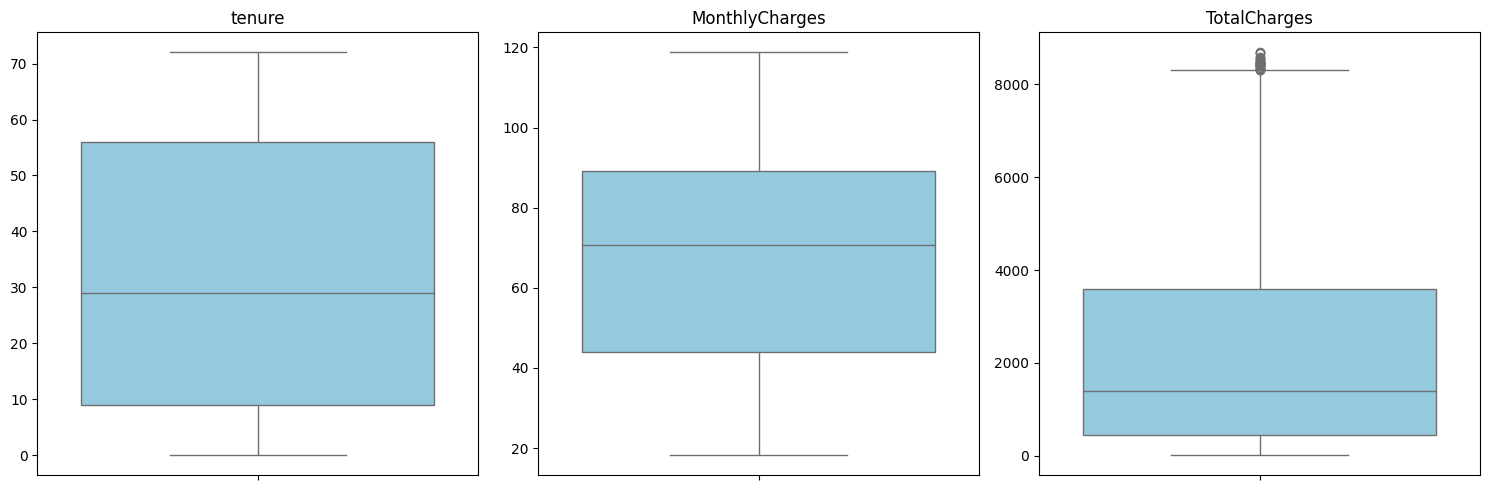

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the numerical columns to plot
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Set up the matplotlib figure layout
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Loop through the columns and create a boxplot for each
for i, col in enumerate(num_cols):
    sns.boxplot(y=df_train[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('')  # Clear the y-label to keep it clean

plt.tight_layout()
plt.show()

the outliers exist only in TotalCharges. So,we handle them. We use the IQR method to replace the outliers with median.

In [113]:
outlier_features = [
    'TotalCharges'
]

for col in outlier_features:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = ((df_train[col] < lower_bound) | (df_train[col] > upper_bound)).sum()
    print(f"Feature '{col}': Removing {outliers_count} outlier rows.")

    df_train = df_train[(df_train[col] >= lower_bound) & (df_train[col] <= upper_bound)]

df_train.head()

Feature 'TotalCharges': Removing 24 outlier rows.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,No,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [114]:
df_train.drop('customerID', axis=1, inplace=True)
df_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,No,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,Female,0,No,No,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,Male,0,No,No,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,Male,0,Yes,No,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,Female,0,Yes,Yes,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,Male,0,No,No,51,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No
5630,Male,1,Yes,No,68,No,No phone service,DSL,Yes,Yes,Yes,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No
5631,Male,0,Yes,Yes,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No
5632,Female,0,No,No,69,Yes,No,DSL,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.30,No


In [115]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder

In [116]:
df_train['Churn'].value_counts()

,count
Churn,
No,4107
Yes,1503


In [117]:
# Filter for only non-numerical columns
non_num_cols = df_train.select_dtypes(include='object').columns

# Loop through and print both the data type and value counts
for col in non_num_cols:
    print(f"Column: {col} | Data Type: {df_train[col].dtype}")
    print(df_train[col].value_counts())
    print("-" * 40 + "\n")

Column: gender | Data Type: object
gender
Male      2902
Female    2708
Name: count, dtype: int64
----------------------------------------

Column: Partner | Data Type: object
Partner
No     2886
Yes    2724
Name: count, dtype: int64
----------------------------------------

Column: Dependents | Data Type: object
Dependents
No     3944
Yes    1666
Name: count, dtype: int64
----------------------------------------

Column: PhoneService | Data Type: object
PhoneService
Yes    5057
No      553
Name: count, dtype: int64
----------------------------------------

Column: MultipleLines | Data Type: object
MultipleLines
No                  2701
Yes                 2356
No phone service     553
Name: count, dtype: int64
----------------------------------------

Column: InternetService | Data Type: object
InternetService
Fiber optic    2462
DSL            1945
No             1203
Name: count, dtype: int64
----------------------------------------

Column: OnlineSecurity | Data Type: object
Online

In [118]:
from sklearn.preprocessing import LabelEncoder
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

# 1. Apply Label Encoding to binary columns
le = LabelEncoder()
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df_train[col] = le.fit_transform(df_train[col])

df_train.head()



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,35,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,0,Mailed check,20.75,700.45,0
1,0,0,0,0,28,0,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,1,Mailed check,35.75,961.40,0
2,1,0,0,0,56,1,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,0,Electronic check,98.60,5581.05,0
3,1,0,1,0,39,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,1,Bank transfer (automatic),20.45,790.00,0
4,0,0,1,1,43,0,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,1,Bank transfer (automatic),51.25,2151.60,0


In [119]:
# Filter for only non-numerical columns
non_num_cols = df_train.select_dtypes(include='object').columns

# Loop through and print both the data type and value counts
for col in non_num_cols:
    print(f"Column: {col} | Data Type: {df_train[col].dtype}")
    print(df_train[col].value_counts())
    print("-" * 40 + "\n")

Column: MultipleLines | Data Type: object
MultipleLines
No                  2701
Yes                 2356
No phone service     553
Name: count, dtype: int64
----------------------------------------

Column: InternetService | Data Type: object
InternetService
Fiber optic    2462
DSL            1945
No             1203
Name: count, dtype: int64
----------------------------------------

Column: OnlineSecurity | Data Type: object
OnlineSecurity
No                     2888
Yes                    1551
No internet service    1171
Name: count, dtype: int64
----------------------------------------

Column: OnlineBackup | Data Type: object
OnlineBackup
No                     2459
Yes                    1948
No internet service    1203
Name: count, dtype: int64
----------------------------------------

Column: DeviceProtection | Data Type: object
DeviceProtection
No                     2485
Yes                    1922
No internet service    1203
Name: count, dtype: int64
-------------------------

In [120]:
manual_mappings = {
    'MultipleLines': {'No': 0, 'Yes': 1, 'No phone service': 2},
    'InternetService': {'Fiber optic': 0, 'DSL': 1, 'No': 2},
    'OnlineSecurity': {'No': 0, 'Yes': 1, 'No internet service': 2},
    'OnlineBackup': {'No': 0, 'Yes': 1, 'No internet service': 2},
    'DeviceProtection': {'No': 0, 'Yes': 1, 'No internet service': 2},
    'TechSupport': {'No': 0, 'Yes': 1, 'No internet service': 2},
    'StreamingTV': {'No': 0, 'Yes': 1, 'No internet service': 2},
    'StreamingMovies': {'No': 0, 'Yes': 1, 'No internet service': 2},

    # Contract Map
    'Contract': {'Month-to-month': 0, 'One year': 1, 'Two year': 2},

    # Payment Method Map
    'PaymentMethod': {
        'Electronic check': 0,
        'Mailed check': 1,
        'Bank transfer (automatic)': 2,
        'Credit card (automatic)': 3
    }
}

# 2. Apply the dictionary mappings to df_train
for col, mapping in manual_mappings.items():
    df_train[col] = df_train[col].map(mapping)

# 3. Apply the identical mappings to df_test to keep them aligned
if 'df_test' in locals() or 'df_test' in globals():
    for col, mapping in manual_mappings.items():
        if col in df_test.columns:
            df_test[col] = df_test[col].map(mapping)

# Check that everything converted successfully to numbers
df_train.head()



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,35,1,0,2,2,2,2,2,2,2,1,0,1,20.75,700.45,0
1,0,0,0,0,28,0,2,1,0,0,1,1,0,0,0,1,1,35.75,961.40,0
2,1,0,0,0,56,1,1,0,0,1,0,0,1,1,0,0,0,98.60,5581.05,0
3,1,0,1,0,39,1,0,2,2,2,2,2,2,2,2,1,2,20.45,790.00,0
4,0,0,1,1,43,0,2,1,0,1,0,1,1,0,1,1,2,51.25,2151.60,0


/tmp/ipykernel_993/3294021947.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_correlation.drop('Churn').values, y=churn_correlation.drop('Churn').index, palette='coolwarm')


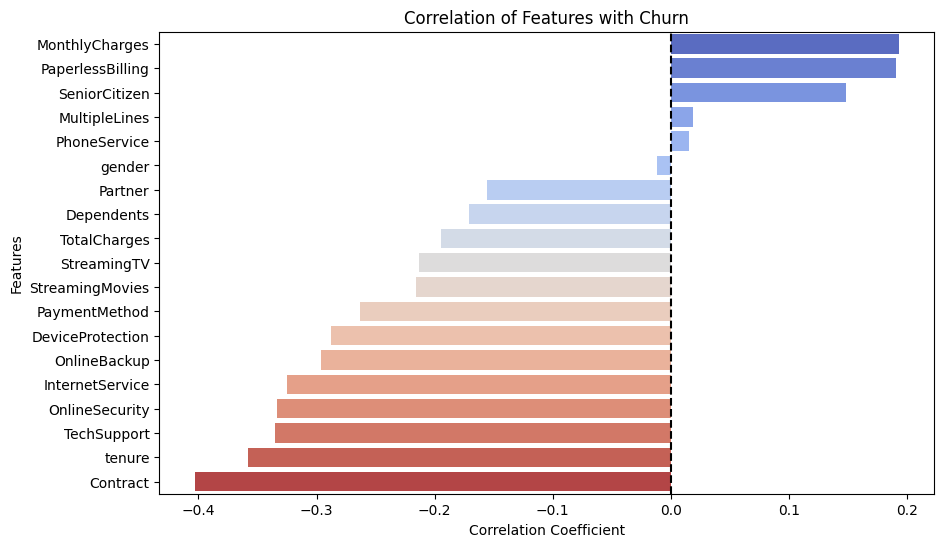

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. First calculate the correlation (this fixes the NameError!)
churn_correlation = df_train.corr()['Churn'].sort_values(ascending=False)

# 2. Plot the correlations
plt.figure(figsize=(10, 6))

# Exclude Churn itself so it doesn't show a perfect 1.0 correlation bar
sns.barplot(x=churn_correlation.drop('Churn').values, y=churn_correlation.drop('Churn').index, palette='coolwarm')

plt.title('Correlation of Features with Churn')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='--') # Add a baseline at 0
plt.show()

In [122]:
#scaling

from sklearn.preprocessing import StandardScaler

# 1. Define the numerical columns that need scaling
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 2. Initialize the StandardScaler
scaler = StandardScaler()

# 3. Fit and transform the numerical columns in df_train
df_train[num_cols] = scaler.fit_transform(df_train[num_cols])

df_train.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,0.104405,1,0,2,2,2,2,2,2,2,1,0,1,-1.540724,-0.692241,0
1,0,0,0,0,-0.180951,0,2,1,0,0,1,1,0,0,0,1,1,-1.021933,-0.572704,0
2,1,0,0,0,0.960475,1,1,0,0,1,0,0,1,1,0,0,0,1.151802,1.543486,0
3,1,0,1,0,0.267466,1,0,2,2,2,2,2,2,2,2,1,2,-1.551100,-0.651220,0
4,0,0,1,1,0.430527,0,2,1,0,1,0,1,1,0,1,1,2,-0.485849,-0.027492,0


In [129]:
df_train['Tenure_Contract_Interaction'] = df_train['tenure'] * df_train['Contract']
df_train['Customer_Lifetime_Value'] = df_train['tenure'] * df_train['MonthlyCharges']

# 2. Update feature sets to include these new columns
X = df_train.drop(columns=['Churn'])
y = df_train['Churn']

# 3. Use the exact variable name (model_rfc) that you trained in cell [98]
importances = model_rfc.feature_importances_

# 4. Perform Feature Selection by mapping importances to the NEW columns
# Note: Since X now has 2 new columns, we pad the array or re-fit if necessary.
# To keep it completely safe, let's quickly re-fit to the new features:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model_rfc.fit(X_train, y_train)

# 5. Display the final feature importance selection
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_rfc.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance Rankings (Including New Engineered Features):")
print(feature_importance_df.to_string(index=False))

Feature Importance Rankings (Including New Engineered Features):
                    Feature  Importance
    Customer_Lifetime_Value    0.140604
               TotalCharges    0.135582
             MonthlyCharges    0.124475
                     tenure    0.124333
                   Contract    0.063884
              PaymentMethod    0.048889
             OnlineSecurity    0.048361
Tenure_Contract_Interaction    0.046165
            InternetService    0.033299
                TechSupport    0.031569
                     gender    0.023752
               OnlineBackup    0.022320
           PaperlessBilling    0.022101
           DeviceProtection    0.021002
              MultipleLines    0.020099
                    Partner    0.019176
            StreamingMovies    0.018475
                StreamingTV    0.017807
              SeniorCitizen    0.017740
                 Dependents    0.016208
               PhoneService    0.004158


In [124]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Separate the features (X) and the target variable (y) from df_train
X = df_train.drop(columns=['Churn'])
y = df_train['Churn']

# 2. Split into 80% training and 20% validation/testing
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Keeps the churn proportion balanced in both sets
)

# 3. Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 4. Evaluate the model on your 20% validation split
y_pred = model.predict(X_val)

print(f"Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_pred))

Validation Accuracy: 0.7790

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       821
           1       0.60      0.54      0.57       301

    accuracy                           0.78      1122
   macro avg       0.72      0.70      0.71      1122
weighted avg       0.77      0.78      0.78      1122



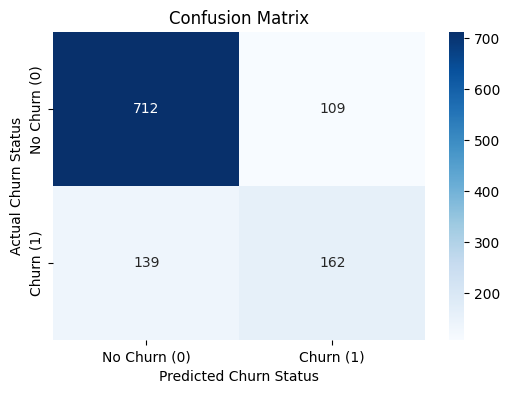

In [125]:
# 1. Compute the confusion matrix using your exact variable names
cm = confusion_matrix(y_val, y_pred)

# 2. Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])

plt.title('Confusion Matrix')
plt.ylabel('Actual Churn Status')
plt.xlabel('Predicted Churn Status')
plt.show()

In [126]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
model_dt = DecisionTreeClassifier(random_state=20)
model_dt.fit(X_train,y_train)
y_pred_dt = model_dt.predict(X_val)
accuracy = accuracy_score(y_val, y_pred_dt)
accuracy

0.7121212121212122

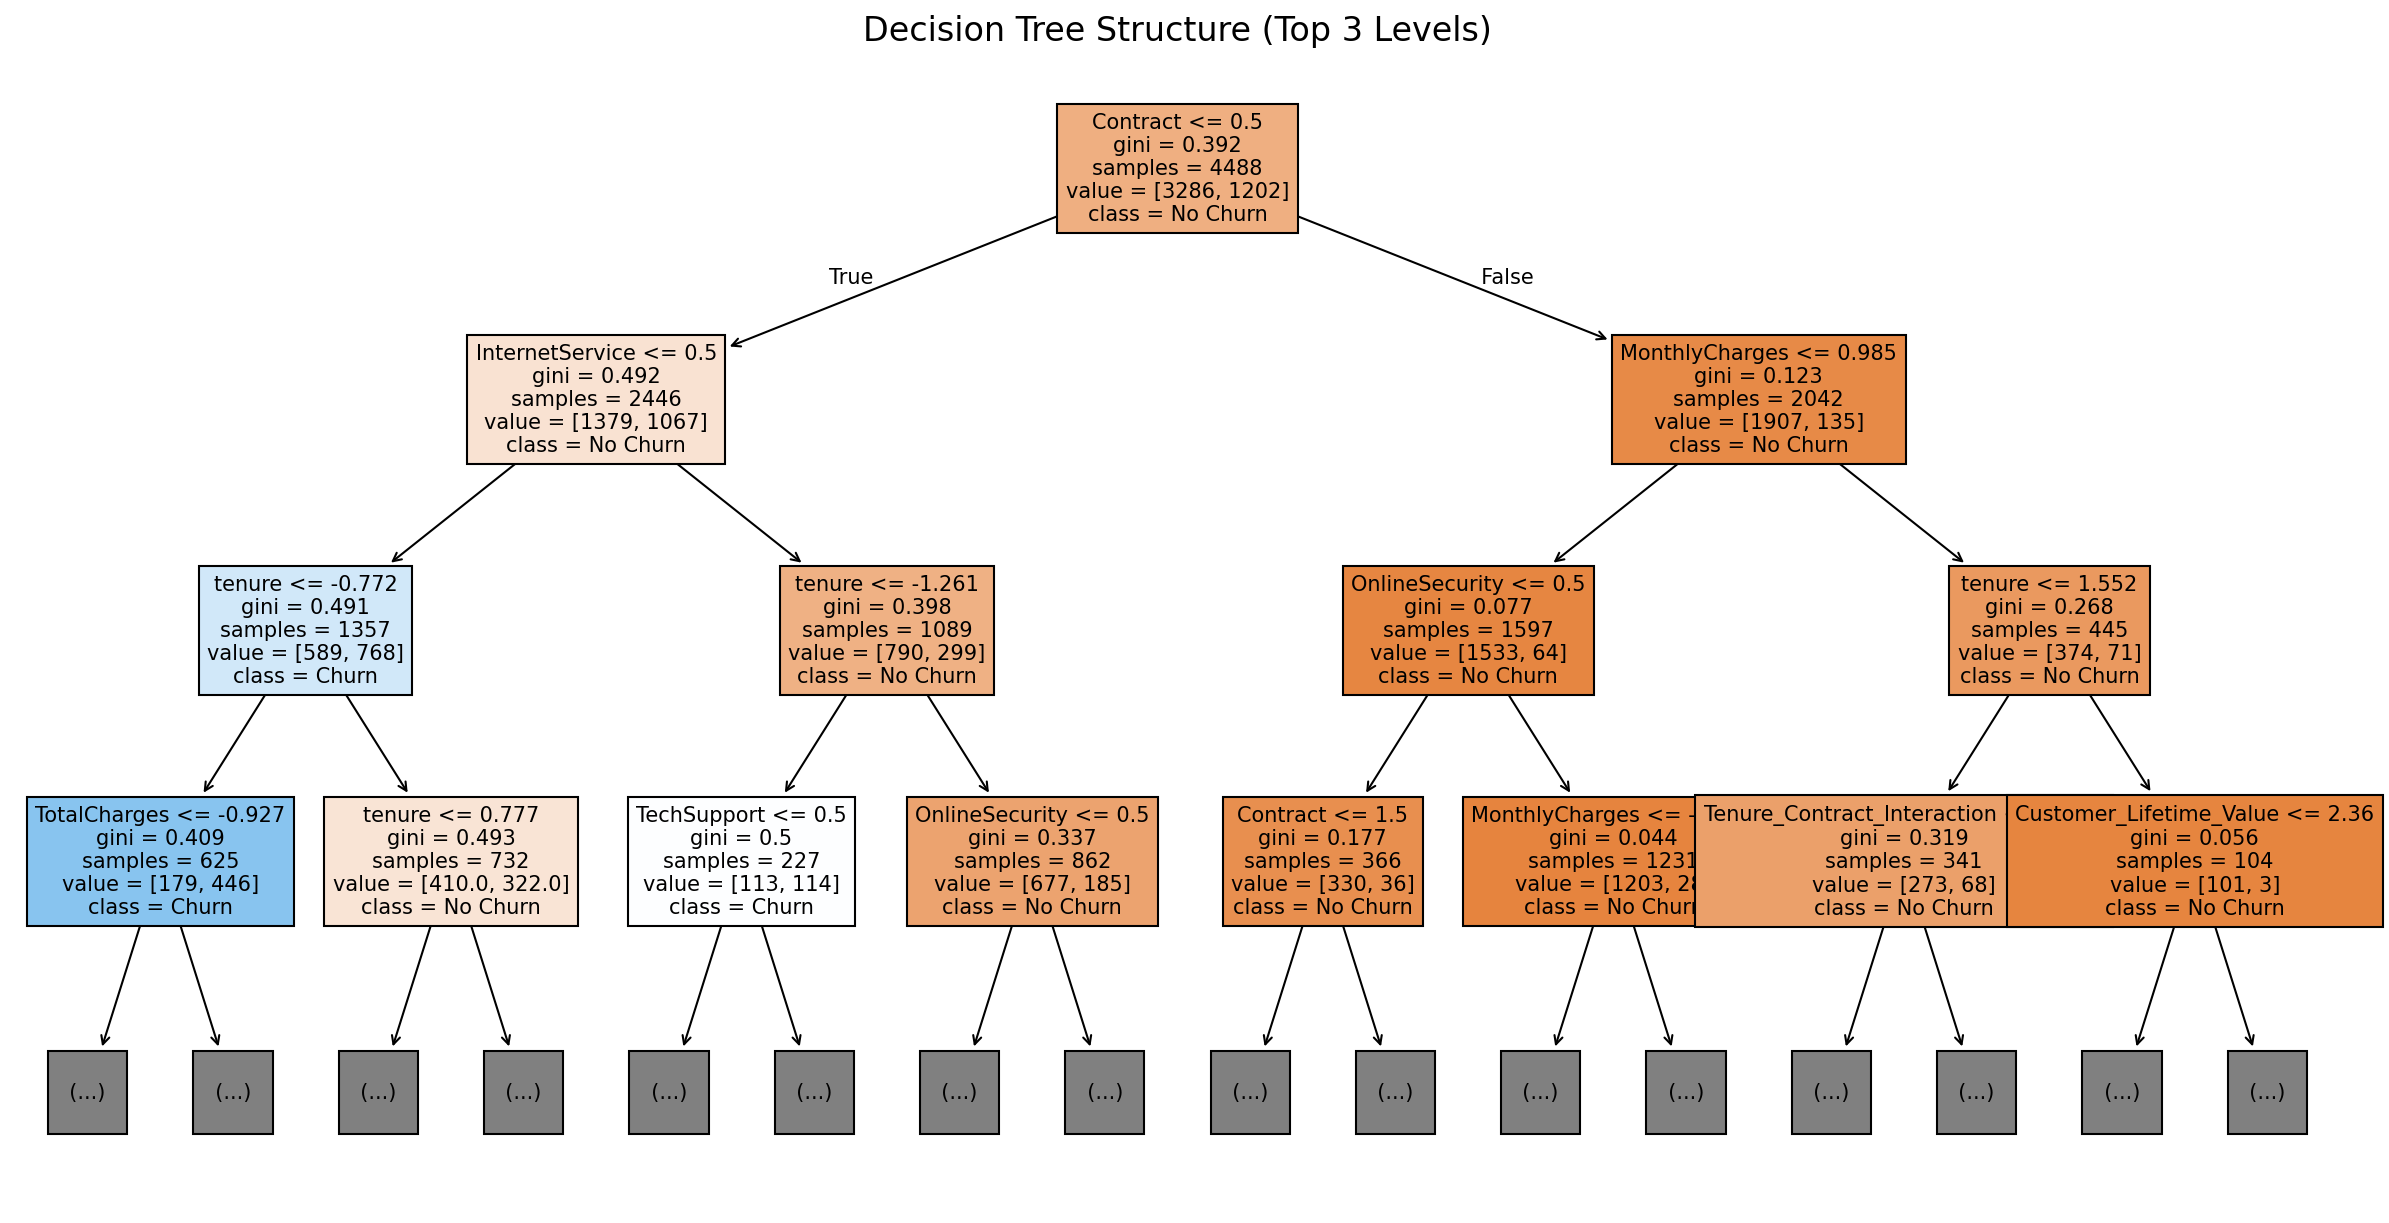

In [127]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names = X.columns.tolist()

# 1. Change figsize to a standard monitor ratio
plt.figure(figsize=(20, 10), dpi=150)

# 2. Add max_depth=3 to keep the visualization clean and readable
plot_tree(
    model_dt,
    max_depth=3,
    filled=True,
    feature_names=feature_names,
    class_names=['No Churn', 'Churn'],
    fontsize=10
)

plt.title("Decision Tree Structure (Top 3 Levels)", fontsize=16)
plt.show()

In [128]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Initialize and train the Random Forest Classifier
model_rfc = RandomForestClassifier(random_state=42)
model_rfc.fit(X_train, y_train)  # Using lowercase y_train

# 2. Make predictions on your 20% validation split
y_pred_rfc = model_rfc.predict(X_val)  # Using X_val

# 3. Calculate and display the score
rfc_accuracy = accuracy_score(y_val, y_pred_rfc)  # Using y_val
print(f"Random Forest Validation Accuracy: {rfc_accuracy:.4f}")

Random Forest Validation Accuracy: 0.7825


In [133]:
from sklearn.model_selection import GridSearchCV

# 1. Define the hyperparameter search space
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 2. Set up GridSearchCV using your correct model name: model_rfc
grid_search = GridSearchCV(
    estimator=model_rfc,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 3. Fit the grid search to your training data
grid_search.fit(X_train, y_train)

# 4. Output the best hyperparameters found
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': 10,
 'min_samples_split': 10,
 'n_estimators': 300}

In [136]:
# 1. Check the best cross-validation score achieved during grid search
print(f"Best Grid Search CV Score: {grid_search.best_score_:.4f}")

# 2. Extract the optimized best model instance
best_model = grid_search.best_estimator_

# 3. Make predictions using your correct validation split variable (X_val)
y_pred_best = best_model.predict(X_val)

# 4. Calculate and display the optimized accuracy score
final_accuracy = accuracy_score(y_val, y_pred_best)
print(f"Tuned Random Forest Validation Accuracy: {final_accuracy:.4f}")

Best Grid Search CV Score: 0.8004
Tuned Random Forest Validation Accuracy: 0.7879


In [142]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

new_data = df_test

new_data['TotalCharges'] = pd.to_numeric(new_data['TotalCharges'], errors='coerce')

for col in ['MonthlyCharges', 'TotalCharges']:
    new_data[col] = new_data[col].fillna(df_train[col].median())

for col in ['gender', 'OnlineSecurity']:
    new_data[col] = new_data[col].fillna(df_train[col].mode()[0])

duplicate_count = new_data.duplicated().sum()
if duplicate_count > 0:
    new_data.drop_duplicates(inplace=True)

if 'customerID' in new_data.columns:
    new_data.drop('customerID', axis=1, inplace=True)

le = LabelEncoder()
binary_cols_test = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols_test:
    if col in new_data.columns:
        new_data[col] = le.fit_transform(new_data[col])

manual_mappings = {
    'MultipleLines': {'No': 0, 'Yes': 1, 'No phone service': 2},
    'InternetService': {'Fiber optic': 0, 'DSL': 1, 'No': 2},
    'OnlineSecurity': {'No': 0, 'Yes': 1, 'No internet service': 2},
    'OnlineBackup': {'No': 0, 'Yes': 1, 'No internet service': 2},
    'DeviceProtection': {'No': 0, 'Yes': 1, 'No internet service': 2},
    'TechSupport': {'No': 0, 'Yes': 1, 'No internet service': 2},
    'StreamingTV': {'No': 0, 'Yes': 1, 'No internet service': 2},
    'StreamingMovies': {'No': 0, 'Yes': 1, 'No internet service': 2},
    'Contract': {'Month-to-month': 0, 'Two year': 1, 'One year': 2},
    'PaymentMethod': {
        'Electronic check': 0,
        'Mailed check': 1,
        'Bank transfer (automatic)': 2,
        'Credit card (automatic)': 3
    }
}
for col, mapping in manual_mappings.items():
    if col in new_data.columns:
        new_data[col] = new_data[col].map(mapping)

Q1 = new_data['TotalCharges'].quantile(0.25)
Q3 = new_data['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
new_data = new_data[(new_data['TotalCharges'] >= lower_bound) & (new_data['TotalCharges'] <= upper_bound)]

new_data['Tenure_Contract_Interaction'] = new_data['tenure'] * new_data['Contract']
new_data['Customer_Lifetime_Value'] = new_data['tenure'] * new_data['MonthlyCharges']

X_new = new_data.drop(columns=['Churn'])
y_new = new_data['Churn']

scaler = StandardScaler()
X_new_scaled = scaler.fit_transform(X_new)

print("Shape of processed test features:", X_new_scaled.shape)

Shape of processed test features: (1409, 21)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [143]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Generate predictions on your processed test features using your best Random Forest model
y_pred_new = grid_search.best_estimator_.predict(X_new_scaled)

# 2. Print out the final accuracy evaluation
print("Accuracy :", accuracy_score(y_new, y_pred_new))

print("\nClassification Report\n")
print(classification_report(y_new, y_pred_new))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_new, y_pred_new))

Accuracy : 0.7913413768630234

Classification Report

              precision    recall  f1-score   support

           0       0.80      0.95      0.87      1044
           1       0.71      0.33      0.45       365

    accuracy                           0.79      1409
   macro avg       0.76      0.64      0.66      1409
weighted avg       0.78      0.79      0.76      1409


Confusion Matrix

[[995  49]
 [245 120]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
